In [1]:
# Execute this code block to install dependencies when running on colab
try:
    import torch
except:
    from os.path import exists
    from wheel.pep425tags import get_abbr_impl, get_impl_ver, get_abi_tag
    platform = '{}{}-{}'.format(get_abbr_impl(), get_impl_ver(), get_abi_tag())
    cuda_output = !ldconfig -p|grep cudart.so|sed -e 's/.*\.\([0-9]*\)\.\([0-9]*\)$/cu\1\2/'
    accelerator = cuda_output[0] if exists('/dev/nvidia0') else 'cpu'

    !pip install -q http://download.pytorch.org/whl/{accelerator}/torch-1.0.0-{platform}-linux_x86_64.whl torchvision

## The Fashion-MNIST Dataset

Fashion-MNIST is a dataset of Zalando’s article images consisting of a training set of 60,000 examples and a test set of 10,000 examples. Each example is a 28×28 grayscale image, associated with a label from 10 classes. Fashion-MNIST is intended to serve as a direct drop-in replacement of the original MNIST dataset for benchmarking machine learning algorithms as it is a more challenging dataset.

For this lab, let's start by loading the Fashion-MNIST dataset using the Torchvision library. When loading, we can transform the images to be flattened vectors of dimension 784 (= 28 x 28).

Once the data has been downloaded, we can plot some of the examples to see what the classes look like.

### Loading the Dataset using PyTorch and the Torchvision Library

In [2]:
import torch
import torchvision
import torchvision.transforms as transforms

batch_size = 256

# dataset construction
transform = transforms.Compose([
    transforms.ToTensor(), # convert to tensor
    transforms.Lambda(lambda x: x.view(image_dim)) # flatten into vector
    ])

train_set = torchvision.datasets.FashionMNIST(
    root='./data/FashionMNIST'
    ,train=True
    ,download=True
    ,transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_set, batch_size=batch_size
)

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.5MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 197kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.30MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 12.6MB/s]


/usr/local/lib/python3.11/dist-packages/torchvision/datasets/mnist.py:76: UserWarning: train_data has been renamed data
  warnings.warn("train_data has been renamed data")


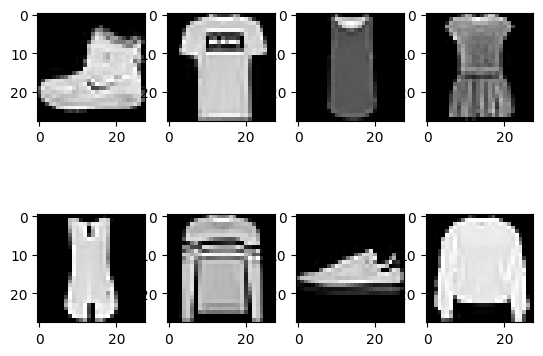

In [3]:
%matplotlib inline

import matplotlib.pyplot as plt

for i in range(8):
    plt.subplot(int(str(24)+str(i+1)))
    plt.imshow(train_set.train_data[i], cmap=plt.get_cmap('gray'))

# show the plot
plt.show()

# Implement an Autoencoder

The next step is to implement a very simple autoencoder algorithm.

Recall from the lecture, an autoencoder is an unsupervised algorithm that consists of an encoder and a decoder. The input passes through an encoder, which typically contains a bottleneck to reduce to the dimensionality of the input. This latent code, or reduced dimensionality representation of the input is then passed through the decoder to reconstruct the input. The reconstruction will be a lossy version of the input. The encoder and decoder are neural networks and learning is achieved in the same manner as with a neural network.

For this implementation, assume the Encoder (defined below) only has an input and an output. There is no hidden layer in the encoder. Assume the dimensionality of the latent space is $64$.

For the Decoder, again, assume it is a simple dense layer without a hidden layer (simply an input and output layer). For the decoder, the output layer should have a Sigmoid non-linearity as opposed to Relu (which may be used for the other layers).

Start by defining the Encoder and Decoder classes.

In [17]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Encoder(nn.Module):
    '''
    simple encoder with no hidden dense layer
    '''
    def __init__(self, input_dim, hidden_dim):
        super(Encoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 784),
            nn.ReLU(),
            nn.Linear(784, hidden_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim, 784),
            nn.ReLU(),
            nn.Linear(784, 28*28),
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x.view(-1, 28*28))
        out = self.decoder(z)
        return out

class Decoder(nn.Module):
    '''
    simple decoder: single dense hidden layer followed by
    output layer with a sigmoid to squish values
    '''
    def __init__(self, input_dim, output_dim):
        super(Decoder, self).__init__()
        self.decoder = nn.Sequential(
            nn.Linear(input_dim, 784),  # Input to hidden layer
            nn.ReLU(),                # Activation function
            nn.Linear(784, output_dim), # Hidden to output layer
            nn.Sigmoid()              # Sigmoid activation for output
        )

    def forward(self, x):
        return self.decoder(x)

Next, let's test the autoencoder implementation to make sure it is functioning and see what the reconstructed images look like.

The code to test your autoencoder is written below. You will simply need to write the code to display your reconstructed images.

In [18]:
import matplotlib.gridspec as gridspec
import os
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

from tqdm.autonotebook import tqdm
from itertools import chain

enc_dim = 64
image_dim = 784  # [flattened]
nEpoch = 10

# construct the encoder, decoder and optimiser
enc = Encoder(image_dim, enc_dim)
dec = Decoder(enc_dim, image_dim)
optimizer = optim.Adam(chain(enc.parameters(), dec.parameters()), lr=1e-3)

# training loop
for epoch in range(nEpoch):
    losses = []
    trainloader = tqdm(train_loader)

    for i, data in enumerate(trainloader, 0):
        inputs, _ = data
        optimizer.zero_grad()

        z = enc(inputs)
        outputs = dec(z)

        loss = F.binary_cross_entropy(outputs, inputs, reduction='sum') / inputs.shape[0]
        loss.backward()
        optimizer.step()

        # keep track of the loss and update the stats
        losses.append(loss.item())
        trainloader.set_postfix(loss=np.mean(losses), epoch=epoch)


    # Display some of the reconstructed images
    # Get a batch of test images
    with torch.no_grad():
        for data in train_loader:  # using train_loader here to display images from training data
                images, _ = data
                num_images_to_display = 8 # change it to display more/less images
                outputs = dec(enc(images[:num_images_to_display]))
                break  # Get out of the loop after getting one batch

        # Plot the original and reconstructed images
        fig, axes = plt.subplots(nrows=2, ncols=num_images_to_display, figsize=(15,5))
        for i in range(num_images_to_display):
            # Original images
            axes[0, i].imshow(images[i].view(28, 28).cpu().numpy(), cmap='gray')
            axes[0, i].set_title('Original')
            axes[0, i].axis('off')
            # Reconstructed images
            axes[1, i].imshow(outputs[i].view(28, 28).cpu().numpy(), cmap='gray')
            axes[1, i].set_title('Reconstructed')
            axes[1, i].axis('off')

        plt.tight_layout()
        plt.show()

  0%|          | 0/469 [00:00<?, ?it/s]

RuntimeError: mat1 and mat2 shapes cannot be multiplied (128x784 and 64x784)

[VAE] Epoch 1, Loss: 292.5499
[VAE] Epoch 2, Loss: 272.9296
[VAE] Epoch 3, Loss: 269.7538
[VAE] Epoch 4, Loss: 267.9181
[VAE] Epoch 5, Loss: 266.6628
[VAE] Epoch 6, Loss: 265.5484
[VAE] Epoch 7, Loss: 264.8891
[VAE] Epoch 8, Loss: 264.2226
[VAE] Epoch 9, Loss: 263.7749
[VAE] Epoch 10, Loss: 263.4294


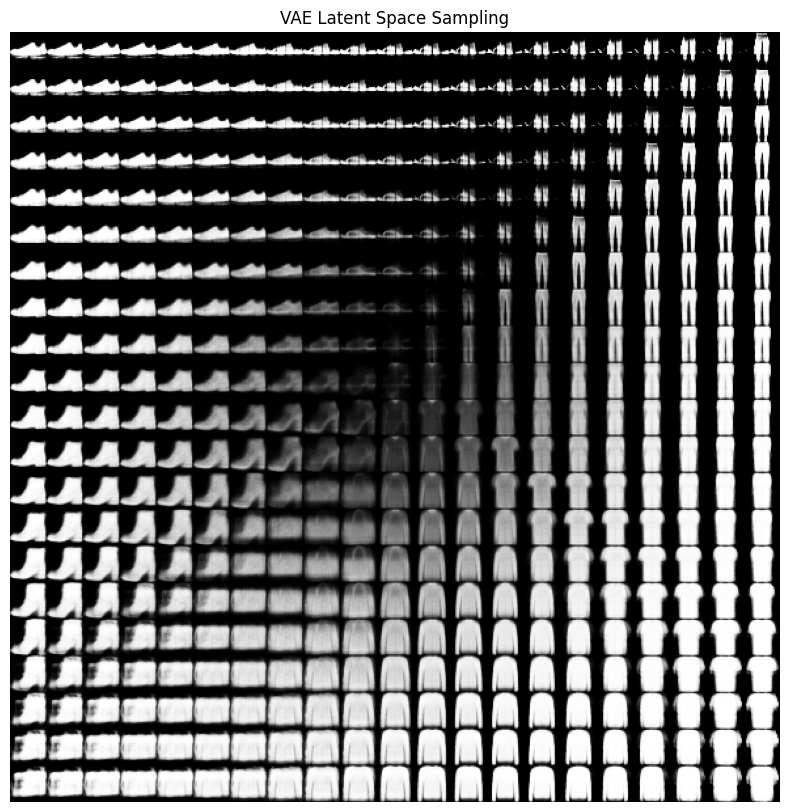

[AE] Epoch 1, Loss: 30.9439
[AE] Epoch 2, Loss: 25.1063
[AE] Epoch 3, Loss: 24.2793
[AE] Epoch 4, Loss: 23.7446
[AE] Epoch 5, Loss: 23.3357
[AE] Epoch 6, Loss: 23.0704
[AE] Epoch 7, Loss: 22.8239
[AE] Epoch 8, Loss: 22.6579
[AE] Epoch 9, Loss: 22.4897
[AE] Epoch 10, Loss: 22.3532


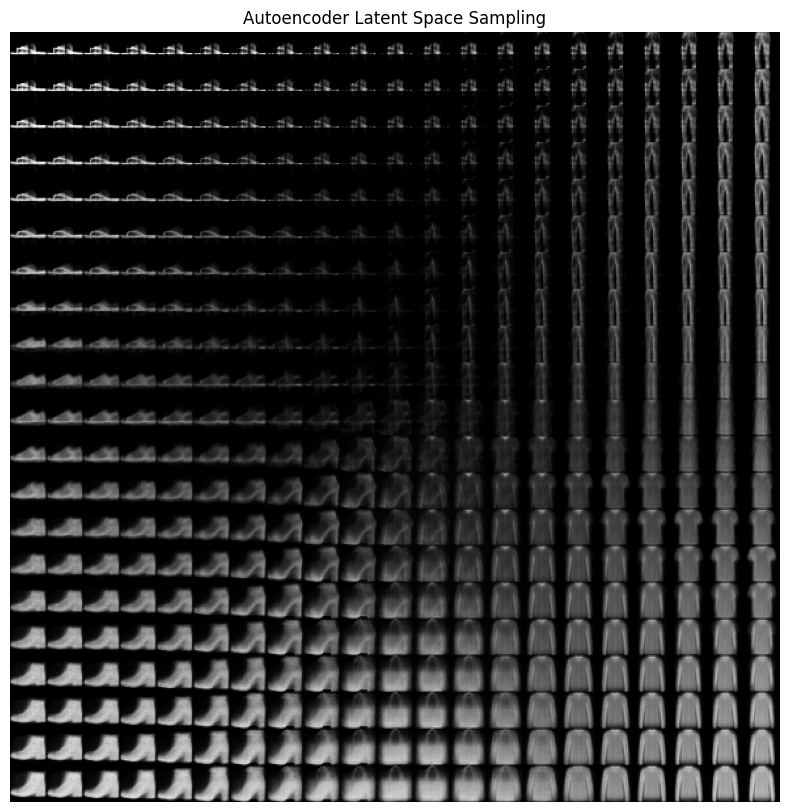

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np

# 超参数设置
LATENT_DIM = 2
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BATCH_SIZE = 128

# 数据加载
transform = transforms.ToTensor()
train_loader = torch.utils.data.DataLoader(
    torchvision.datasets.FashionMNIST('./data', train=True, download=True, transform=transform),
    batch_size=BATCH_SIZE, shuffle=True
)

# -----------------------
# 定义 VAE 模型
# -----------------------
class VAE(nn.Module):
    def __init__(self):
        super(VAE, self).__init__()
        self.fc1 = nn.Linear(28*28, 400)
        self.fc21 = nn.Linear(400, LATENT_DIM)
        self.fc22 = nn.Linear(400, LATENT_DIM)
        self.fc3 = nn.Linear(LATENT_DIM, 400)
        self.fc4 = nn.Linear(400, 28*28)

    def encode(self, x):
        h = F.relu(self.fc1(x))
        return self.fc21(h), self.fc22(h)  # 均值和对数方差

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = F.relu(self.fc3(z))
        return torch.sigmoid(self.fc4(h))

    def forward(self, x):
        mu, logvar = self.encode(x.view(-1, 28*28))
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

# VAE loss 函数
def vae_loss(recon_x, x, mu, logvar):
    BCE = F.binary_cross_entropy(recon_x, x.view(-1, 28*28), reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD

# -----------------------
# 训练 VAE
# -----------------------
vae = VAE().to(DEVICE)
optimizer = torch.optim.Adam(vae.parameters(), lr=1e-3)

vae.train()
for epoch in range(10):
    total_loss = 0
    for x, _ in train_loader:
        x = x.to(DEVICE)
        optimizer.zero_grad()
        recon, mu, logvar = vae(x)
        loss = vae_loss(recon, x, mu, logvar)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f'[VAE] Epoch {epoch+1}, Loss: {total_loss/len(train_loader.dataset):.4f}')

# -----------------------
# 系统采样潜空间并可视化 VAE
# -----------------------
def plot_latent_space(decoder, model_name):
    n = 21
    digit_size = 28
    scale = 4
    figure = np.zeros((digit_size * n, digit_size * n))

    grid_x = np.linspace(-scale, scale, n)
    grid_y = np.linspace(scale, -scale, n)

    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            z = torch.tensor([[xi, yi]], dtype=torch.float32).to(DEVICE)
            with torch.no_grad():
                out = decoder(z)
            digit = out.view(digit_size, digit_size).cpu().numpy()
            figure[i * digit_size: (i + 1) * digit_size,
                   j * digit_size: (j + 1) * digit_size] = digit

    plt.figure(figsize=(10, 10))
    plt.imshow(figure, cmap='gray')
    plt.axis('off')
    plt.title(f"{model_name} Latent Space Sampling")
    plt.savefig(f'{model_name}_latent_space.png')
    plt.show()

# 可视化 VAE 潜空间
vae.eval()
plot_latent_space(vae.decode, "VAE")

# -----------------------
# 定义标准 Autoencoder
# -----------------------
class AE(nn.Module):
    def __init__(self):
        super(AE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(28*28, 400),
            nn.ReLU(),
            nn.Linear(400, LATENT_DIM)
        )
        self.decoder = nn.Sequential(
            nn.Linear(LATENT_DIM, 400),
            nn.ReLU(),
            nn.Linear(400, 28*28),
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x.view(-1, 28*28))
        out = self.decoder(z)
        return out

# -----------------------
# 训练 Autoencoder
# -----------------------
ae = AE().to(DEVICE)
optimizer = torch.optim.Adam(ae.parameters(), lr=1e-3)
loss_fn = nn.MSELoss(reduction='sum')

ae.train()
for epoch in range(10):
    total_loss = 0
    for x, _ in train_loader:
        x = x.to(DEVICE)
        optimizer.zero_grad()
        out = ae(x)
        loss = loss_fn(out, x.view(-1, 28*28))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f'[AE] Epoch {epoch+1}, Loss: {total_loss/len(train_loader.dataset):.4f}')

# 可视化 Autoencoder 潜空间
ae.eval()
plot_latent_space(ae.decoder, "Autoencoder")